# Laptop data set cleaning, data analysis, and regression

In [1]:
import numpy as np
import pandas as pd
import sys
import re

In [2]:
# Looking at original features
# if this does not work, go to https://www.kaggle.com/datasets/ehtishamsadiq/uncleaned-laptop-price-dataset/code, download and replace the contents of pd.read_csv with the file path prefaced by an r (ie r"myfilepath")
laptop_raw = pd.read_csv("data/laptopData.csv")
laptop_raw.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [3]:
# Checking for invalid values
laptop_raw.dtypes
laptop_raw['Inches'].unique()

array(['13.3', '15.6', '15.4', '14', '12', nan, '17.3', '13.5', '12.5',
       '13', '18.4', '13.9', '11.6', '25.6', '35.6', '12.3', '27.3', '24',
       '33.5', '?', '31.6', '17', '15', '14.1', '11.3', '10.1'],
      dtype=object)

In [4]:
laptop_raw.replace(to_replace='?', value=np.nan, inplace=True)
laptop_raw.replace(to_replace='nan', value=np.nan, inplace=True)
laptop_raw['Inches'] = laptop_raw['Inches'].astype(np.float64)
laptop_raw.dtypes

Unnamed: 0          float64
Company              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price               float64
dtype: object

Inches column is cleaned, moving on to RAM as it is the next column we expect to be saved as a float. Since units are consistent our function will just take out any character that is not part of the number value.

In [5]:
laptop_raw['Ram'] = laptop_raw['Ram'].apply(lambda x: re.sub('[^0-9.]', '', x) if isinstance(x, str) else x).replace('', np.nan).astype(('float64'))
laptop_raw['Ram'].unique()

array([ 8., 16.,  4., nan,  2., 12., 64.,  6., 32., 24.,  1.])

Ram is cleaned, on to Memory. This column essentially stores two features, the type of non-volatile storage and the bite measure of that amount of storage. We'll write a function that writes storage type to a new column (that we'll likely leave unused during ML process). Then we'll deal with the bites, converting everything into GB for simplicity and removing any non numeric characters.

In [6]:
# extract_storage_type looks for anything that has numbers in it then returns the alphabetical parts, giving us the storage type
def extract_storage_type(s):
    if pd.isnull(s):
        return np.nan
    parts = re.findall(r'\d+\.?\d*\s*(?:GB|TB)\s*([A-Za-z ]+)', s)
    return ' + '.join(part.strip() for part in parts)

def total_storage_in_gb(s):
    if not isinstance(s, str):
        return np.nan

    matches = re.findall(r'\d+\.?\d*\s*(?:GB|TB)', s)
    total_gb = 0

    for item in matches:
        number = float(re.search(r'\d+\.?\d*', item).group())
        if 'TB' in item:
            number *= 1024
        total_gb += number

    return float(total_gb)

laptop_raw['Storage Type'] = laptop_raw['Memory'].apply(extract_storage_type)
laptop_raw['Memory'] = laptop_raw['Memory'].apply(total_storage_in_gb).astype('float64')
laptop_raw['Storage Type'].unique()

array(['SSD', 'Flash Storage', 'HDD', nan, 'SSD + HDD', 'SSD + SSD',
       'Hybrid', 'Flash Storage + HDD', 'HDD + HDD', 'SSD + Hybrid'],
      dtype=object)

In [7]:
laptop_raw['Memory'].unique()

array([ 128.,  256.,  512.,  500., 1024.,   nan, 1152.,   64.,   32.,
       1280., 2304., 2048., 1536.,  756., 2176.,   16.,  768., 2560.,
       1088.,  180.,  240.,    8.,  508.])

Memory has been transformed to a single value, while still keeping storage type in a seperate column, if the type of storage turns out to be a significant determinant of price, we can still use it in ML stage. We have a single number to measure the GB of non-volatile storage available.

In [8]:
laptop_raw['Weight'].unique()

array(['1.37kg', '1.34kg', '1.86kg', '1.83kg', '2.1kg', '2.04kg', '1.3kg',
       '1.6kg', '2.2kg', '0.92kg', '1.22kg', nan, '2.5kg', '1.62kg',
       '1.91kg', '2.3kg', '1.35kg', '1.88kg', '1.89kg', '1.65kg',
       '2.71kg', '1.2kg', '1.44kg', '2.8kg', '2kg', '2.65kg', '2.77kg',
       '3.2kg', '1.49kg', '2.4kg', '2.13kg', '2.43kg', '1.7kg', '1.4kg',
       '1.8kg', '1.9kg', '3kg', '1.252kg', '2.7kg', '2.02kg', '1.63kg',
       '1.96kg', '1.21kg', '2.45kg', '1.25kg', '1.5kg', '2.62kg',
       '1.38kg', '1.58kg', '1.85kg', '1.23kg', '2.16kg', '2.36kg',
       '7.2kg', '2.05kg', '1.32kg', '1.75kg', '0.97kg', '2.56kg',
       '1.48kg', '1.74kg', '1.1kg', '1.56kg', '2.03kg', '1.05kg', '5.4kg',
       '4.4kg', '1.90kg', '1.29kg', '2.0kg', '1.95kg', '2.06kg', '1.12kg',
       '3.49kg', '3.35kg', '2.23kg', '2.9kg', '4.42kg', '2.69kg',
       '2.37kg', '4.7kg', '3.6kg', '2.08kg', '4.3kg', '1.68kg', '1.41kg',
       '4.14kg', '2.18kg', '2.24kg', '2.67kg', '4.1kg', '2.14kg',
       '1.36kg', '

In [9]:
laptop_raw['Weight'] = laptop_raw['Weight'].apply(lambda x: re.sub('[^0-9.]', '', x) if isinstance(x, str) else x).replace('', np.nan).astype(('float64'))
laptop_raw['Weight'].unique()

array([1.370e+00, 1.340e+00, 1.860e+00, 1.830e+00, 2.100e+00, 2.040e+00,
       1.300e+00, 1.600e+00, 2.200e+00, 9.200e-01, 1.220e+00,       nan,
       2.500e+00, 1.620e+00, 1.910e+00, 2.300e+00, 1.350e+00, 1.880e+00,
       1.890e+00, 1.650e+00, 2.710e+00, 1.200e+00, 1.440e+00, 2.800e+00,
       2.000e+00, 2.650e+00, 2.770e+00, 3.200e+00, 1.490e+00, 2.400e+00,
       2.130e+00, 2.430e+00, 1.700e+00, 1.400e+00, 1.800e+00, 1.900e+00,
       3.000e+00, 1.252e+00, 2.700e+00, 2.020e+00, 1.630e+00, 1.960e+00,
       1.210e+00, 2.450e+00, 1.250e+00, 1.500e+00, 2.620e+00, 1.380e+00,
       1.580e+00, 1.850e+00, 1.230e+00, 2.160e+00, 2.360e+00, 7.200e+00,
       2.050e+00, 1.320e+00, 1.750e+00, 9.700e-01, 2.560e+00, 1.480e+00,
       1.740e+00, 1.100e+00, 1.560e+00, 2.030e+00, 1.050e+00, 5.400e+00,
       4.400e+00, 1.290e+00, 1.950e+00, 2.060e+00, 1.120e+00, 3.490e+00,
       3.350e+00, 2.230e+00, 2.900e+00, 4.420e+00, 2.690e+00, 2.370e+00,
       4.700e+00, 3.600e+00, 2.080e+00, 4.300e+00, 

In [10]:
# We clean out 0.002 as a weight because this is a value outside of the reasonable range we'd expect
laptop_raw['Weight'].replace(0.0002, np.nan, inplace=True)
laptop_raw['Weight'].unique()

array([ 1.37 ,  1.34 ,  1.86 ,  1.83 ,  2.1  ,  2.04 ,  1.3  ,  1.6  ,
        2.2  ,  0.92 ,  1.22 ,    nan,  2.5  ,  1.62 ,  1.91 ,  2.3  ,
        1.35 ,  1.88 ,  1.89 ,  1.65 ,  2.71 ,  1.2  ,  1.44 ,  2.8  ,
        2.   ,  2.65 ,  2.77 ,  3.2  ,  1.49 ,  2.4  ,  2.13 ,  2.43 ,
        1.7  ,  1.4  ,  1.8  ,  1.9  ,  3.   ,  1.252,  2.7  ,  2.02 ,
        1.63 ,  1.96 ,  1.21 ,  2.45 ,  1.25 ,  1.5  ,  2.62 ,  1.38 ,
        1.58 ,  1.85 ,  1.23 ,  2.16 ,  2.36 ,  7.2  ,  2.05 ,  1.32 ,
        1.75 ,  0.97 ,  2.56 ,  1.48 ,  1.74 ,  1.1  ,  1.56 ,  2.03 ,
        1.05 ,  5.4  ,  4.4  ,  1.29 ,  1.95 ,  2.06 ,  1.12 ,  3.49 ,
        3.35 ,  2.23 ,  2.9  ,  4.42 ,  2.69 ,  2.37 ,  4.7  ,  3.6  ,
        2.08 ,  4.3  ,  1.68 ,  1.41 ,  4.14 ,  2.18 ,  2.24 ,  2.67 ,
        4.1  ,  2.14 ,  1.36 ,  2.25 ,  2.15 ,  2.19 ,  2.54 ,  3.42 ,
        5.8  ,  1.28 ,  2.33 ,  1.45 ,  2.79 ,  8.23 ,  1.26 ,  1.84 ,
        2.6  ,  2.26 ,  3.25 ,  1.59 ,  1.13 ,  1.42 ,  1.78 ,  1.15 ,
      

It looks like the Price, the most significant feature in this case, is stored in a currency other than USD. Upon further inspection it looks like the data was scraped from an ecommerce website that uses Pakistani rupees. We need to convert the Price into USD, then examine the data to see if there are any outliers that are erroneous or otherwise need to be dropped. Then we will continue to cleaning/transforming the data to prep it for use in a regression ml model. 

In [11]:
laptop_raw['Price'] = laptop_raw['Price']/284.9
laptop_raw.describe()
laptop_raw.head()
# make sure to only run this once, if you divide by the conversion again it will make Price much smaller

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Storage Type
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8.0,128.0,Intel Iris Plus Graphics 640,macOS,1.37,250.539429,SSD
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8.0,128.0,Intel HD Graphics 6000,macOS,1.34,168.113455,Flash Storage
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256.0,Intel HD Graphics 620,No OS,1.86,107.532468,SSD
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16.0,512.0,AMD Radeon Pro 455,macOS,1.83,474.536104,SSD
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8.0,256.0,Intel Iris Plus Graphics 650,macOS,1.37,337.296623,SSD


Additional Transformations need to be made in order to facilitate data visualization. Cpu and Price may have a relationship but it will be hard to understand with so many specific CPUs. As a start I will group them by their brand. 

In [12]:
laptop_raw_copy = laptop_raw
laptop_raw_copy.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Storage Type
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8.0,128.0,Intel Iris Plus Graphics 640,macOS,1.37,250.539429,SSD
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8.0,128.0,Intel HD Graphics 6000,macOS,1.34,168.113455,Flash Storage
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256.0,Intel HD Graphics 620,No OS,1.86,107.532468,SSD
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16.0,512.0,AMD Radeon Pro 455,macOS,1.83,474.536104,SSD
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8.0,256.0,Intel Iris Plus Graphics 650,macOS,1.37,337.296623,SSD


#### For AMD it seems they have 4 different series of CPU within this data:
1. AMD A Series
2. AMD E-Series
3. AMD FX
4. AMD Ryzen
<br> 
#### Then for Intel they have:
1. Intel Atom
2. Intel Celeron Dual Core
3. Intel Celeron Quad Core
4. Intel Core i3
5. Intel Core i5
6. Intel Core i7
7. Intel Core M
8. Intel Pentium Dual Core 
9. Intel Pentium Quad Core
10. Intel Xeon

In [13]:
# here we narrow the CPUs down to brand and series
CPU_PATTERNS = [
    (r'AMD A\d+[ -]Series', 'AMD A-Series'),
    (r'AMD E\d*[ -]Series', 'AMD E-Series'),
    (r'AMD FX(?:\s*\d+)?', 'AMD FX'),
    (r'AMD Ryzen(?:\s*\d+)?', 'AMD Ryzen'),
    (r'Intel Atom(?:\s*\w+)?', 'Intel Atom'),
    (r'Intel Celeron Dual Core.*', 'Intel Celeron Dual Core'),
    (r'Intel Celeron Quad Core.*', 'Intel Celeron Quad Core'),
    (r'Intel Core i3(?:[- ]?\d{4,5}[A-Z]*)?', 'Intel Core i3'),
    (r'Intel Core i5(?:[- ]?\d{4,5}[A-Z]*)?', 'Intel Core i5'),
    (r'Intel Core i7(?:[- ]?\d{4,5}[A-Z]*)?', 'Intel Core i7'),
    (r'Intel Core M(?:\s*\w+)?', 'Intel Core M'),
    (r'Intel Pentium Dual Core.*', 'Intel Pentium Dual Core'),
    (r'Intel Pentium Quad Core.*', 'Intel Pentium Quad Core'),
    (r'Intel Xeon.*', 'Intel Xeon'),
]

def extract_cpus(df, column='Cpu', new_column='Cpu Brand'):
    def label_cpu(text):
        if pd.isnull(text):
            return ''
        for pat, label in CPU_PATTERNS:
            if re.search(pat, text, flags=re.IGNORECASE):
                return label
        return ''
    df[new_column] = df[column].apply(label_cpu)
    return df

df = laptop_raw_copy
df = extract_cpus(df, column='Cpu', new_column='Cpu Brand')

#The CPU pattern before produced over a dozen bars when visualized, to make this simpler we'll lump some Series together

CPU_PATTERNS = [
    (r'AMD A\d+[ -]Series', 'AMD Series'),
    (r'AMD E\d*[ -]Series', 'AMD Series'),
    (r'AMD Series', 'AMD Series'),
    (r'AMD FX(?:\s*\d+)?', 'AMD FX'),
    (r'AMD Ryzen(?:\s*\d+)?', 'AMD Ryzen'),
    (r'Intel Atom(?:\s*\w+)?', 'Intel Atom'),
    (r'Intel Celeron(?:\s+\w+)?', 'Intel Celeron'),
    (r'Intel Core i[3579](?:[- ]?\d{4,5}[A-Z]*)?', 'Intel Core'),
    (r'Intel Core M(?:\s*\w+)?', 'Intel Core'),
    (r'Intel Pentium(?:\s+\w+)?', 'Intel Pentium'),
    (r'Intel Xeon(?:.*)?', 'Intel Xeon')
]

df = extract_cpus(df, column='Cpu', new_column='Cpu Brand Concise')

df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Storage Type,Cpu Brand,Cpu Brand Concise
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8.0,128.0,Intel Iris Plus Graphics 640,macOS,1.37,250.539429,SSD,Intel Core i5,Intel Core
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8.0,128.0,Intel HD Graphics 6000,macOS,1.34,168.113455,Flash Storage,Intel Core i5,Intel Core
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256.0,Intel HD Graphics 620,No OS,1.86,107.532468,SSD,Intel Core i5,Intel Core
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16.0,512.0,AMD Radeon Pro 455,macOS,1.83,474.536104,SSD,Intel Core i7,Intel Core
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8.0,256.0,Intel Iris Plus Graphics 650,macOS,1.37,337.296623,SSD,Intel Core i5,Intel Core


Reminder that the dataframe we are working on at the moment is saved simply as df, laptop_raw_copy and laptop_raw are alternatives that currently do not have the CPU brand transformation

In [14]:
df.describe()

,Unnamed: 0,Inches,Ram,Memory,Weight,Price
count,1273.000000,1272.000000,1273.000000,1272.000000,1271.000000,1273.000000
mean,652.674784,15.130818,8.462687,621.525157,2.079253,210.445118
std,376.493027,1.954436,5.564408,481.133282,0.806019,131.036332
min,0.000000,10.100000,1.000000,8.000000,0.690000,32.540260
25%,327.000000,14.000000,4.000000,256.000000,1.500000,112.020779
50%,652.000000,15.600000,8.000000,500.000000,2.040000,183.085714
75%,980.000000,15.600000,8.000000,1024.000000,2.320000,278.460468
max,1302.000000,35.600000,64.000000,2560.000000,11.100000,1140.592208


It is worth considering that specs that lead to greater performance may not be the greatest predictor of price. The brand behind the product may be significant as well as the type of laptop itself. It is difficult to work with an objective measure of each specs' performance so we will use online resources to help sort these specs into tiers based on their performance.

In [15]:
df_numeric = df.copy()

cpu_performance_tiers = {
    'Intel Celeron': 1,
    'Intel Atom': 1,
    'Intel Pentium': 2,
    'AMD Series': 2,
    'AMD FX': 3,
    'Intel Core': 4,
    'AMD Ryzen': 4,
    'Intel Xeon': 5
}
df_numeric['CPU Tiers'] = df_numeric['Cpu Brand Concise'].map(cpu_performance_tiers)

company_marketing_tiers = {
    'Apple': 5,
    'HP': 4,
    'Acer': 3,
    'Asus': 3,
    'Dell': 4,
    'Lenovo': 4,
    'nan': 0,
    'Chuwi': 1,
    'MSI': 3,
    'Microsoft': 4,
    'Toshiba': 2,
    'Huawei': 3,
    'Xiaomi': 3,
    'Vero': 1,
    'Razer': 3,
    'Mediacom': 1,
    'Samsung': 5,
    'Google': 2,
    'Fujitsu': 2,
    'LG': 3
}
df_numeric['Company Marketing Tier'] = df_numeric['Company'].map(company_marketing_tiers)

df_numeric.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Storage Type,Cpu Brand,Cpu Brand Concise,CPU Tiers,Company Marketing Tier
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8.0,128.0,Intel Iris Plus Graphics 640,macOS,1.37,250.539429,SSD,Intel Core i5,Intel Core,4.0,5.0
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8.0,128.0,Intel HD Graphics 6000,macOS,1.34,168.113455,Flash Storage,Intel Core i5,Intel Core,4.0,5.0
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256.0,Intel HD Graphics 620,No OS,1.86,107.532468,SSD,Intel Core i5,Intel Core,4.0,4.0
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16.0,512.0,AMD Radeon Pro 455,macOS,1.83,474.536104,SSD,Intel Core i7,Intel Core,4.0,5.0
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8.0,256.0,Intel Iris Plus Graphics 650,macOS,1.37,337.296623,SSD,Intel Core i5,Intel Core,4.0,5.0


In [16]:
df_numeric['TypeName'].unique()

array(['Ultrabook', 'Notebook', nan, 'Gaming', '2 in 1 Convertible',
       'Workstation', 'Netbook'], dtype=object)

Below is the sum of all engineered features for this data set made into one cell for neatness.

In [17]:
laptop_price_tiers = {
    'Ultrabook': 4,
    'Notebook': 3,
    np.nan: 0,
    'Gaming': 5,
    '2 in 1 Convertible': 3,
    'Workstation': 5,
    'Netbook': 1
}
laptop_performance_tiers = {
    'Ultrabook': 3,
    'Notebook': 3,
    np.nan: 0,
    'Gaming': 5,
    '2 in 1 Convertible': 2,
    'Workstation': 5,
    'Netbook': 1
}

def parse_screen_resolution(resolution_str):
    if pd.isnull(resolution_str):
        return None, None
    
    # Extract pixel resolution
    match = re.search(r'(\d+)\s*[xX]\s*(\d+)', resolution_str)
    pixel_count = None
    if match:
        width, height = map(int, match.groups())
        pixel_count = width * height
    
    # Detect marketing terms
    marketing_terms = []
    terms_map = {
        'Retina': r'\bRetina\b',
        '4K': r'\b4K\b|\b3840x2160\b',
        'UHD': r'\bUHD\b',
        'Full HD': r'\bFull\s*HD\b|\b1920x1080\b',
        'Touchscreen': r'\bTouch\b|\bTouchscreen\b',
        'IPS Panel': r'\bIPS\b',
        'OLED': r'\bOLED\b',
        'QHD': r'\bQHD\b|\b2560x1440\b'
    }
    
    for label, pattern in terms_map.items():
        if re.search(pattern, resolution_str, flags=re.IGNORECASE):
            marketing_terms.append(label)
    
    marketing_str = ', '.join(marketing_terms) if marketing_terms else None
    
    return pixel_count, marketing_str
df_numeric[['PixelCount', 'DisplayFeatures']] = df_numeric['ScreenResolution'].apply(
    lambda x: pd.Series(parse_screen_resolution(x))
)

GPU_PATTERNS = [
    (r'AMD\s+FirePro(?:\s*[\w-]+)?',                'AMD FirePro'),
    (r'AMD\s+Radeon\s+Pro(?:\s*[\w-]+)?',           'AMD Radeon Pro'),
    (r'AMD\s+Radeon\s+RX(?:\s*[\w-]+)?',            'AMD Radeon RX'),
    (r'AMD\s+Radeon(?!\s+(Pro|RX))(?:\s*[\w-]+)?',  'AMD Radeon'),
    (r'AMD\s+Graphics(?:\s*[\w-]+)?',               'AMD Graphics'),

    (r'ARM\s+Mali(?:\s*[\w-]+)?',                   'ARM Mali'),

    (r'Nvidia\s+GeForce\s+GTX(?:\s*[\w-]+)?',       'Nvidia GeForce GTX'),
    (r'Nvidia\s+GeForce\s+MX(?:\s*[\w-]+)?',        'Nvidia GeForce MX'),
    (r'Nvidia\s+Quadro(?:\s*[\w-]+)?',              'Nvidia Quadro'),

    (r'Intel\s+Iris\s+Pro\s+Graphics(?:\s*[\w-]+)?','Intel Iris Pro Graphics'),
    (r'Intel\s+Iris\s+Plus\s+Graphics(?:\s*[\w-]+)?','Intel Iris Plus Graphics'),
    (r'Intel\s+Iris\s+Graphics(?:\s*[\w-]+)?',     'Intel Iris Graphics'),
    (r'Intel\s+UHD\s+Graphics(?:\s*[\w-]+)?',      'Intel UHD Graphics'),
    (r'Intel\s+HD\s+Graphics(?:\s*[\w-]+)?',       'Intel HD Graphics'),
    (r'Intel\s+Graphics(?:\s*[\w-]+)?',            'Intel Graphics'),
]

GPU_PATTERNS = [
    (r'AMD\s+FirePro(?:\s*[\w-]+)?',                'AMD FirePro'),
    (r'AMD\s+Radeon\s+Pro(?:\s*[\w-]+)?',           'AMD Radeon Pro'),
    (r'AMD\s+Radeon\s+RX(?:\s*[\w-]+)?',            'AMD Radeon RX'),
    (r'AMD\s+Radeon(?!\s+(Pro|RX))(?:\s*[\w-]+)?',  'AMD Radeon'),
    (r'AMD\s+Graphics(?:\s*[\w-]+)?',               'AMD Graphics'),
    (r'ARM\s+Mali(?:\s*[\w-]+)?',                   'ARM Mali'),
    (r'Nvidia\s+GeForce\s+GTX(?:\s*[\w-]+)?',       'Nvidia GeForce GTX'),
    (r'Nvidia\s+GeForce\s+MX(?:\s*[\w-]+)?',        'Nvidia GeForce MX'),
    (r'Nvidia\s+Quadro(?:\s*[\w-]+)?',              'Nvidia Quadro'),
    (r'Intel\s+Iris\s+Pro\s+Graphics(?:\s*[\w-]+)?','Intel Iris Pro Graphics'),
    (r'Intel\s+Iris\s+Plus\s+Graphics(?:\s*[\w-]+)?','Intel Iris Plus Graphics'),
    (r'Intel\s+Iris\s+Graphics(?:\s*[\w-]+)?',      'Intel Iris Graphics'),
    (r'Intel\s+UHD\s+Graphics(?:\s*[\w-]+)?',       'Intel UHD Graphics'),
    (r'Intel\s+HD\s+Graphics(?:\s*[\w-]+)?',        'Intel HD Graphics'),
    (r'Intel\s+Graphics(?:\s*[\w-]+)?',             'Intel Graphics'),
]

gpu_performance_tiers = {
    'Intel Graphics': 1,
    'ARM Mali': 1,
    'Intel HD Graphics': 2,
    'Intel Iris Graphics': 2,
    'Intel UHD Graphics': 2,
    'Intel Iris Plus Graphics': 3,
    'Intel Iris Pro Graphics': 3,
    'Nvidia GeForce MX': 3,
    'AMD Radeon': 3,
    'AMD Radeon Pro': 4,
    'AMD Radeon RX': 4,
    'Nvidia GeForce GTX': 5,
    'Nvidia Quadro': 5,
    'AMD FirePro': 5,
    'AMD Graphics': 2,
    '': 0
}

def extract_gpus(df, column='Gpu', brand_col='Gpu Brand Concise', tier_col='GPU Tiers'):
    compiled = [(re.compile(pat, re.IGNORECASE), label) for pat, label in GPU_PATTERNS]

    def label_gpu(text):
        t = '' if pd.isnull(text) else str(text).strip()
        for rx, label in compiled:
            if rx.search(t):
                return label
        return ''

    # Create brand column
    df[brand_col] = df[column].apply(label_gpu)

    # Map to performance tier
    df[tier_col] = df[brand_col].map(gpu_performance_tiers)

    return df

storage_tiers = {
    'SSD + SSD': 5,
    'SSD': 4,
    'SSD + HDD': 4,
    'SSD + Hybrid': 4,
    'Hybrid': 3,
    'Flash Storage + HDD': 3,
    'HDD': 2,
    'HDD + HDD': 2,
    'Flash Storage': 2,
    np.nan: 0
}

df_numeric['Laptop Type Price Tiers'] = df_numeric['TypeName'].map(laptop_price_tiers)
df_numeric['Laptop Performance Tiers'] = df_numeric['TypeName'].map(laptop_performance_tiers)
df_numeric['GPU Tiers'] = df_numeric['Gpu'].map(laptop_performance_tiers)
df_numeric = extract_gpus(df_numeric, column='Gpu', brand_col='Gpu Brand Concise', tier_col='GPU Tiers')
df_numeric['Storage_Tier'] = df_numeric['Storage Type'].map(storage_tiers)
df_numeric.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,...,Cpu Brand Concise,CPU Tiers,Company Marketing Tier,PixelCount,DisplayFeatures,Laptop Type Price Tiers,Laptop Performance Tiers,GPU Tiers,Gpu Brand Concise,Storage_Tier
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8.0,128.0,Intel Iris Plus Graphics 640,macOS,...,Intel Core,4.0,5.0,4096000.0,"Retina, IPS Panel",4,3,3,Intel Iris Plus Graphics,4
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8.0,128.0,Intel HD Graphics 6000,macOS,...,Intel Core,4.0,5.0,1296000.0,NaN,4,3,2,Intel HD Graphics,2
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256.0,Intel HD Graphics 620,No OS,...,Intel Core,4.0,4.0,2073600.0,Full HD,3,3,2,Intel HD Graphics,4
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16.0,512.0,AMD Radeon Pro 455,macOS,...,Intel Core,4.0,5.0,5184000.0,"Retina, IPS Panel",4,3,4,AMD Radeon Pro,4
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8.0,256.0,Intel Iris Plus Graphics 650,macOS,...,Intel Core,4.0,5.0,4096000.0,"Retina, IPS Panel",4,3,3,Intel Iris Plus Graphics,4


In [18]:
# Dropping non numeric features
df_numeric = df_numeric.drop(columns=['Storage Type', 'Cpu Brand', 'Cpu Brand Concise', 'OpSys', 'Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Gpu', 'Cpu Brand Concise', 'DisplayFeatures', 'Gpu Brand Concise'])
df_numeric.head()

,Unnamed: 0,Inches,Ram,Memory,Weight,Price,CPU Tiers,Company Marketing Tier,PixelCount,Laptop Type Price Tiers,Laptop Performance Tiers,GPU Tiers,Storage_Tier
0,0.0,13.3,8.0,128.0,1.37,250.539429,4.0,5.0,4096000.0,4,3,3,4
1,1.0,13.3,8.0,128.0,1.34,168.113455,4.0,5.0,1296000.0,4,3,2,2
2,2.0,15.6,8.0,256.0,1.86,107.532468,4.0,4.0,2073600.0,3,3,2,4
3,3.0,15.4,16.0,512.0,1.83,474.536104,4.0,5.0,5184000.0,4,3,4,4
4,4.0,13.3,8.0,256.0,1.37,337.296623,4.0,5.0,4096000.0,4,3,3,4


In [19]:
df_numeric.dtypes

Unnamed: 0                  float64
Inches                      float64
Ram                         float64
Memory                      float64
Weight                      float64
Price                       float64
CPU Tiers                   float64
Company Marketing Tier      float64
PixelCount                  float64
Laptop Type Price Tiers       int64
Laptop Performance Tiers      int64
GPU Tiers                     int64
Storage_Tier                  int64
dtype: object

In [20]:
# We still have some features saved as integers so we take care of it with this function
def convert_all_to_float64(df):
    return df.astype('float64')

df_numeric = convert_all_to_float64(df_numeric)

df_numeric.dtypes

Unnamed: 0                  float64
Inches                      float64
Ram                         float64
Memory                      float64
Weight                      float64
Price                       float64
CPU Tiers                   float64
Company Marketing Tier      float64
PixelCount                  float64
Laptop Type Price Tiers     float64
Laptop Performance Tiers    float64
GPU Tiers                   float64
Storage_Tier                float64
dtype: object

Done with data prep for machine learning, on to setting the prediction target and getting the predictor variables.

In [21]:
y = df_numeric.Price

In [22]:
df_numeric = df_numeric.dropna()
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

<Axes: >

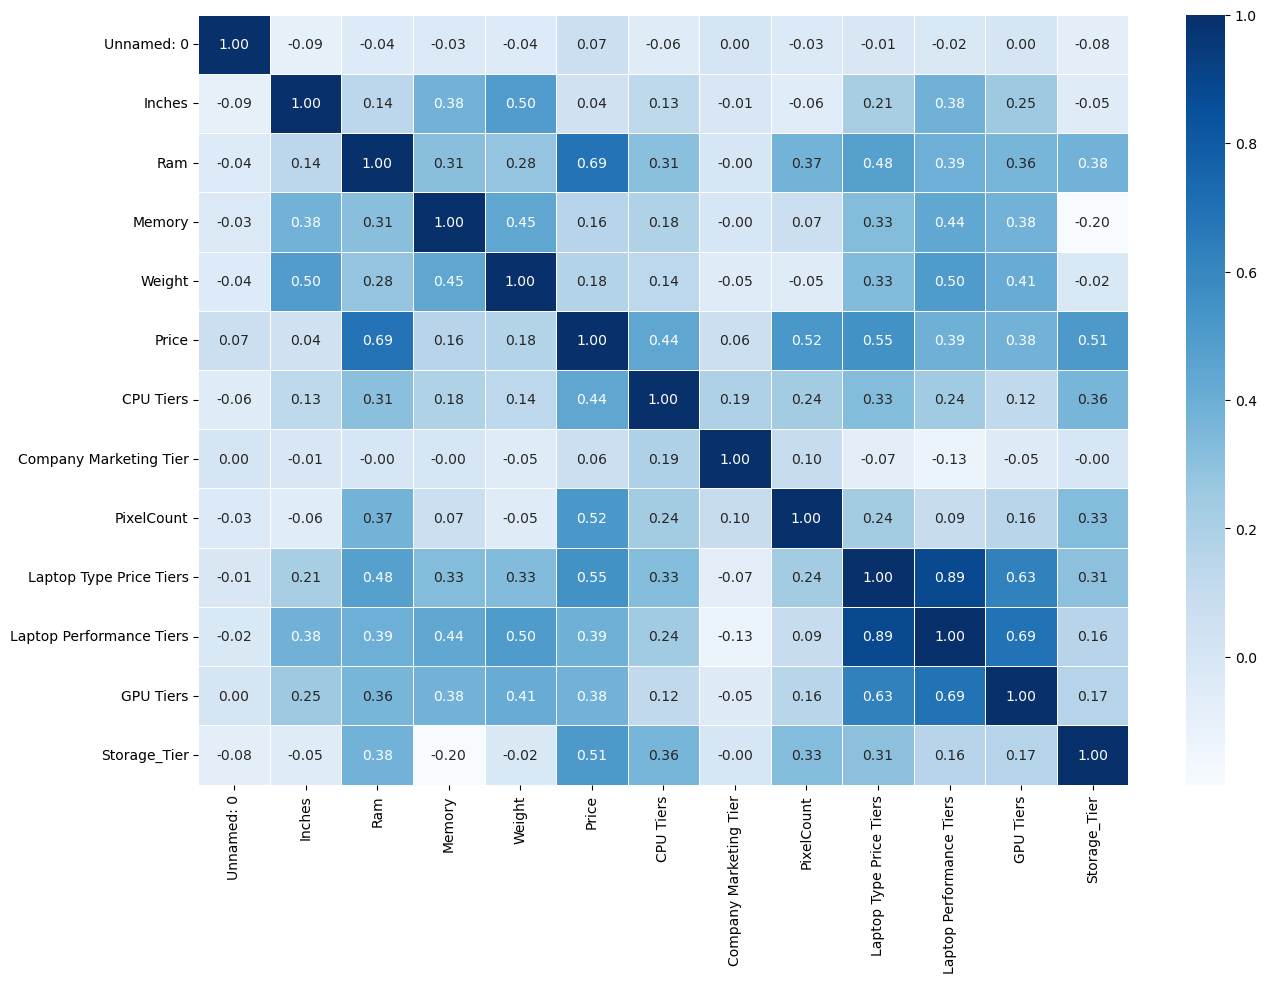

In [23]:
# here we examine the correlation between features in the dataset
correlation_matrix = df_numeric.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', linewidths=0.5, fmt='.2f')

In [24]:
df_numeric.columns

Index(['Unnamed: 0', 'Inches', 'Ram', 'Memory', 'Weight', 'Price', 'CPU Tiers',
       'Company Marketing Tier', 'PixelCount', 'Laptop Type Price Tiers',
       'Laptop Performance Tiers', 'GPU Tiers', 'Storage_Tier'],
      dtype='object')

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, accuracy_score

predictor_list = ['Inches', 'Ram', 'Memory', 'Weight', 'CPU Tiers',
       'Company Marketing Tier', 'PixelCount', 'Laptop Type Price Tiers',
       'Laptop Performance Tiers', 'GPU Tiers', 'Storage_Tier']
X = df_numeric[predictor_list]
y = df_numeric.Price

# Train/test split
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

In [26]:
import time
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_validate

def evaluate_models_reg(models, X_train, y_train, X_test, y_test, cv=5):
    rows = []
    start_total = time.time()

    for model in models:
        start_model = time.time()

        # Cross-val on train only (no leakage)
        scores = cross_validate(
            model, X_train, y_train, cv=cv, n_jobs=-1,
            scoring=['neg_mean_absolute_error', 'neg_mean_squared_error', 'r2'],
            return_train_score=True
        )

        # Mean train metrics from CV folds
        cv_train_mae = -np.mean(scores['train_neg_mean_absolute_error'])
        cv_train_mse = -np.mean(scores['train_neg_mean_squared_error'])
        cv_train_rmse = np.sqrt(cv_train_mse)
        cv_train_r2 = np.mean(scores['train_r2'])

        # Fit on full training set, evaluate on both train and test
        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        test_pred  = model.predict(X_test)

        train_mae  = mean_absolute_error(y_train, train_pred)
        train_mse  = mean_squared_error(y_train, train_pred)
        train_rmse = np.sqrt(train_mse)
        train_r2   = r2_score(y_train, train_pred)

        test_mae  = mean_absolute_error(y_test, test_pred)
        test_mse  = mean_squared_error(y_test, test_pred)
        test_rmse = np.sqrt(test_mse)
        test_r2   = r2_score(y_test, test_pred)

        rows.append({
            'Algorithm': model.__class__.__name__,
            # CV metrics (on train via CV)
            'CV Train R2':   cv_train_r2,
            'CV Train MAE':  cv_train_mae,
            'CV Train MSE':  cv_train_mse,
            'CV Train RMSE': cv_train_rmse,
            # Fit/eval metrics
            'Train R2':   train_r2,
            'Test R2':    test_r2,
            'Train MAE':  train_mae,
            'Test MAE':   test_mae,
            'Train MSE':  train_mse,
            'Test MSE':   test_mse,
            'Train RMSE': train_rmse,
            'Test RMSE':  test_rmse,
            'Model Time (s)': time.time() - start_model,
        })

    df_results = pd.DataFrame(rows).set_index('Algorithm').sort_values(by='Test R2', ascending=False)
    df_results.attrs['Total Time (s)'] = time.time() - start_total
    return df_results

In [28]:

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor,
    BaggingRegressor, AdaBoostRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
# from lightgbm import LGBMRegressor  # Uncomment if you have lightgbm installed

# Define models
models = [
    LinearRegression(),
    Ridge(random_state=ord("S")),
    Lasso(random_state=ord("S")),
    ElasticNet(random_state=ord("S")),
    DecisionTreeRegressor(random_state=ord("S")),
    RandomForestRegressor(random_state=ord("S")),
    GradientBoostingRegressor(random_state=ord("S")),
    XGBRegressor(random_state=ord("S")),
    ExtraTreesRegressor(random_state=ord("S")),
    BaggingRegressor(random_state=ord("S")),
    AdaBoostRegressor(random_state=ord("S")),
    CatBoostRegressor(random_state=ord("S"), verbose=False),
    # LGBMRegressor(random_state=ord("S"), verbose=False),
    SVR(),
    KNeighborsRegressor()
]

results = evaluate_models_reg(models, train_X, train_y, val_X, val_y, cv=5)

# Clean & combine results into one table
results_df = pd.DataFrame(results)
results_df = results_df.round(3)  # Round to 3 decimal places
results_df = results_df.sort_values(by='Test R2', ascending=False)

# Reorder columns for clarity
results_df = results_df[[
    'CV Train R2', 'Train R2', 'Test R2',
    'CV Train MAE', 'Train MAE', 'Test MAE',
    'CV Train RMSE', 'Train RMSE', 'Test RMSE',
    'Model Time (s)'
]]

# Display results
results.round(3)

,CV Train R2,CV Train MAE,CV Train MSE,CV Train RMSE,Train R2,Test R2,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Model Time (s)
Algorithm,,,,,,,,,,,,,
XGBRegressor,0.983,9.852,270.939,16.460,0.979,0.803,11.164,36.410,324.714,4174.481,18.020,64.610,0.306
CatBoostRegressor,0.941,22.393,930.849,30.510,0.936,0.795,23.262,35.794,1019.774,4342.348,31.934,65.896,7.559
GradientBoostingRegressor,0.870,33.550,2060.610,45.394,0.862,0.764,34.602,41.641,2189.411,4987.040,46.791,70.619,0.372
RandomForestRegressor,0.957,17.121,682.120,26.117,0.957,0.724,16.904,38.706,675.924,5851.020,25.999,76.492,1.299
ExtraTreesRegressor,0.988,4.557,189.003,13.748,0.986,0.709,5.284,42.256,219.581,6164.755,14.818,78.516,1.093
BaggingRegressor,0.947,18.252,844.907,29.067,0.945,0.695,18.270,40.062,869.101,6462.658,29.481,80.391,0.195
DecisionTreeRegressor,0.988,4.556,189.003,13.748,0.986,0.643,5.284,48.419,219.581,7566.768,14.818,86.987,0.107
Lasso,0.679,51.688,5083.283,71.297,0.676,0.637,51.708,54.192,5129.449,7696.627,71.620,87.730,0.885
Ridge,0.681,51.877,5043.469,71.017,0.678,0.636,51.913,54.247,5088.664,7711.100,71.335,87.813,1.269


After Running through most common ML regressors, best accuracy acheived was guessing the price with an average error of $36.410, and R^2 ended up being .803, meaning 80% of the variation is explained by the model 

It is worth noting that this data is based on a scrape of a resale site, new latptops may turn out to have differently correlated features. In this data it seems that marketing for these laptops was completely irrelevent, only 0.06 correlated to price. The specs and their performance in a computing context seem to be significant enough to estimate price more often than not, with guesses bassed on those features only being wrong 1/5 of the time. 